In [19]:
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt
import serial 

In [9]:
import zipfile

zip_path = r"C:\Users\Bianca\Documents\proiectSBC-schimbarea lumozitatii farurilor\ML_Car_headlight.v1i.yolov5pytorch.zip"
extract_path = r"C:\Users\Bianca\Documents\SBC-proiect\extracted"

zip_file = zipfile.ZipFile(zip_path, 'r')
zip_file.extractall(extract_path)
zip_file.close()

print("Extras în:", extract_path)


Extras în: C:\Users\Bianca\Documents\SBC-proiect\extracted


Se citesc 1567 imagini din train...
Se citesc 448 imagini din valid...


C:\Users\Bianca\SBC\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Începe antrenarea 
Epoch 1/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.7741 - loss: 0.0222 - val_accuracy: 0.7612 - val_loss: 0.0159
Epoch 2/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.8079 - loss: 0.0143 - val_accuracy: 0.7679 - val_loss: 0.0162
Epoch 3/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.8283 - loss: 0.0120 - val_accuracy: 0.8125 - val_loss: 0.0140
Epoch 4/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.8577 - loss: 0.0089 - val_accuracy: 0.8393 - val_loss: 0.0141
Epoch 5/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.8736 - loss: 0.0066 - val_accuracy: 0.8103 - val_loss: 0.0152
Epoch 6/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.8896 - loss: 0.0051 - val_accuracy: 0.8259 - val_loss: 0.0147
Epoch 7/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.8909 - loss: 0.0045 - val_accuracy: 0.8170 - val_loss: 0.0153
Epoch 8/12
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.9036 - lo

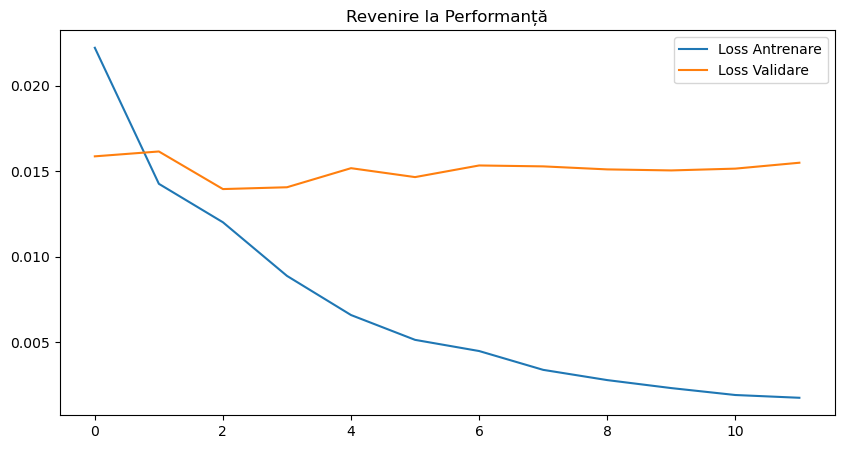

In [10]:

DATA_DIR = r"C:\Users\Bianca\Documents\SBC-proiect\extracted" 
IMG_SIZE = 128

def incarca_date_rapid(nume_folder):
    cale_img = os.path.join(DATA_DIR, nume_folder, "images")
    cale_lbl = os.path.join(DATA_DIR, nume_folder, "labels")
    imagini, tinte = [], []

    if not os.path.exists(cale_img): return np.array([]), np.array([])

    fisiere = os.listdir(cale_img)
    
    fisiere = fisiere[:2000] 

    print(f"Se citesc {len(fisiere)} imagini din {nume_folder}...")

    for fisier in fisiere:
        if fisier.endswith(".jpg") or fisier.endswith(".png"):
            # Citire și Resize
            path_full = os.path.join(cale_img, fisier)
            img = cv2.imread(path_full)
            if img is None: continue
            
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0 # Normalizare (Lab 5)
            
            # Etichete
            nume_txt = os.path.splitext(fisier)[0] + ".txt"
            path_txt = os.path.join(cale_lbl, nume_txt)
            box = [0, 0, 0, 0] 
            if os.path.exists(path_txt):
                with open(path_txt, "r") as f:
                    line = f.readline()
                    if line:
                        parts = line.split()
                        box = [float(p) for p in parts[1:5]]
            
            imagini.append(img)
            tinte.append(box)
    return np.array(imagini), np.array(tinte)

X_train, y_train = incarca_date_rapid("train")
X_val, y_val = incarca_date_rapid("valid")

model = models.Sequential([
    # Strat 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    # Strat 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Strat 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dense(4, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

print("\n Începe antrenarea ")

history = model.fit(
    X_train, y_train,
    epochs=12,         
    batch_size=16,      
    validation_data=(X_val, y_val),
    verbose=1
)

model.save('model_proiect_SBC.keras')

# Grafic
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss Antrenare')
plt.plot(history.history['val_loss'], label='Loss Validare')
plt.title('Revenire la Performanță')
plt.legend()
plt.show()

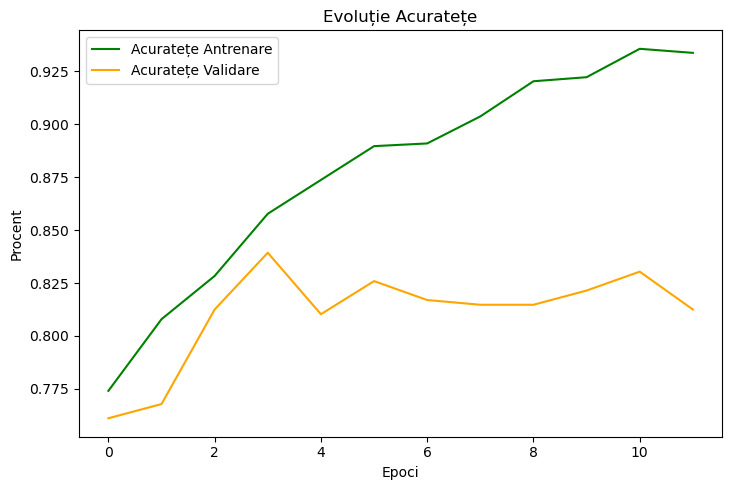

In [30]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acuratețe Antrenare', color='green')
plt.plot(history.history['val_accuracy'], label='Acuratețe Validare', color='orange')
plt.title('Evoluție Acuratețe')
plt.xlabel('Epoci')
plt.ylabel('Procent')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
model.save('model_proiect_SBC.keras')
np.save('X_train_final.npy', X_train)
np.save('X_val_final.npy', X_val)
print(" Totul a fost salvat local")

 Totul a fost salvat local


In [12]:
import numpy as np
from tensorflow.keras.models import load_model
model = load_model('model_proiect_SBC.keras')
X_train = np.load('X_train_final.npy')
X_val = np.load('X_val_final.npy')
print(" Modelul și datele sunt gata")

 Modelul și datele sunt gata


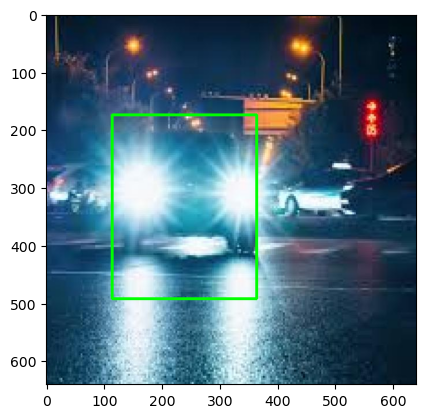

In [13]:
def testeaza_poza(cale_imagine):
    img_bgr = cv2.imread(cale_imagine)
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) 

    img_input = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    img_input = img_input / 255.0
    
    img_input = np.expand_dims(img_input, axis=0)

    pred = model.predict(img_input, verbose=0)
    
    x, y, w, h = pred[0]

    h_orig, w_orig, _ = img_rgb.shape
    x_c = int(x * w_orig)
    y_c = int(y * h_orig)
    w_box = int(w * w_orig)
    h_box = int(h * h_orig)

    x_min = int(x_c - w_box/2)
    y_min = int(y_c - h_box/2)
    x_max = int(x_c + w_box/2)
    y_max = int(y_c + h_box/2)

    img_final = img_rgb.copy()
    cv2.rectangle(img_final, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)

    plt.imshow(img_final)
    plt.show()
testeaza_poza(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i143_png.rf.2f3cdbd4658e6c791e94a51c371b9438.jpg")

In [14]:

IMG_SIZE = 128
NUME_MODEL = 'model_proiect_SBC.keras'

if os.path.exists(NUME_MODEL):
    model = tf.keras.models.load_model(NUME_MODEL)
    print("Modelul a fost incarcat")
else:
    print("Nu gasesc fisierul")

def faza_automata(cale_imagine):
   
    if not os.path.exists(cale_imagine):
        print(f" Fișierul nu exista: {cale_imagine}")
        return

    img_bgr = cv2.imread(cale_imagine)
    if img_bgr is None: return
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    h_orig, w_orig, _ = img_rgb.shape

    img_input = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    img_input = img_input / 255.0
    
    img_input = np.expand_dims(img_input, axis=0)
    
    pred = model.predict(img_input, verbose=0)
    x, y, w, h = pred[0]

    aria_detectata = w * h
    
    PRAG = 0.005 

    img_final = img_rgb.copy()
    
    x_c, y_c = int(x * w_orig), int(y * h_orig)
    w_box, h_box = int(w * w_orig), int(h * h_orig)
    
    x_min = int(x_c - w_box/2)
    y_min = int(y_c - h_box/2)
    x_max = int(x_c + w_box/2)
    y_max = int(y_c + h_box/2)

    if aria_detectata > PRAG:

        decizie = "FAZA SCURTA (DETECTAT)"
        culoare_box = (0, 255, 0)    # Verde (Chenarul AI)
        culoare_text = (255, 255, 0) # Galben (Avertisment)
        
        cv2.rectangle(img_final, (x_min, y_min), (x_max, y_max), culoare_box, 3)
       
        cv2.line(img_final, (x_min, y_min), (x_max, y_max), culoare_box, 1)
        
    else:
     
        decizie = "FAZA LUNGA (LIBER)"
        culoare_text = (0, 255, 0)   # Verde (Safe)
      
    cv2.rectangle(img_final, (0, 0), (w_orig, 60), (0, 0, 0), -1)
    
    cv2.putText(img_final, f"SISTEM: {decizie}", (20, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, culoare_text, 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_final)
    plt.title(f"Analiza AI (Arie: {aria_detectata:.4f})")
    plt.axis('off')
    plt.show()

Modelul a fost incarcat


TEST 1 


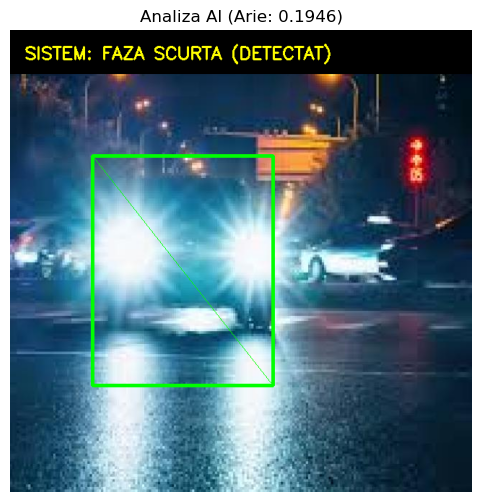

In [15]:

print("TEST 1 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i143_png.rf.2f3cdbd4658e6c791e94a51c371b9438.jpg")


TEST 2


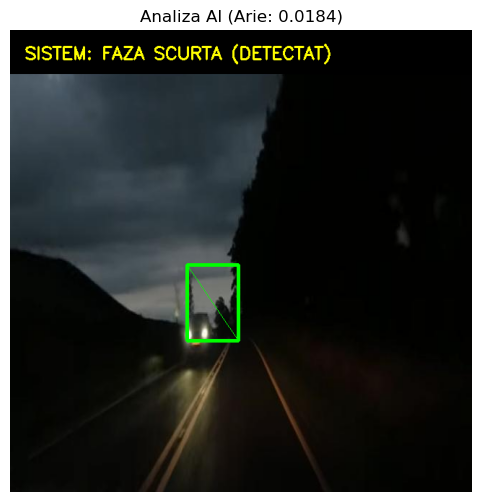

In [16]:
print("TEST 2")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i178_png.rf.4cbc387e093f7119ec57383d7b913f28.jpg")


TEST 3 


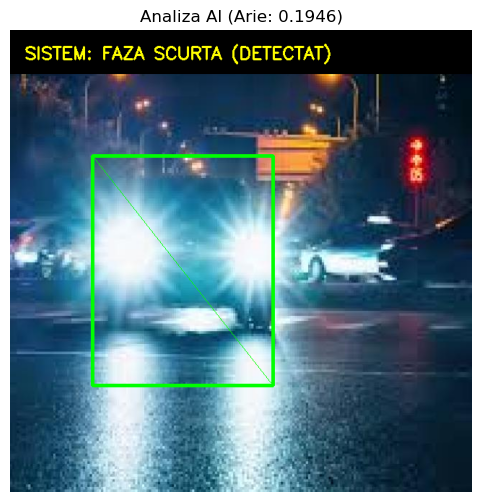

In [17]:

print("TEST 3 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i143_png.rf.2f3cdbd4658e6c791e94a51c371b9438.jpg")


TEST 4 


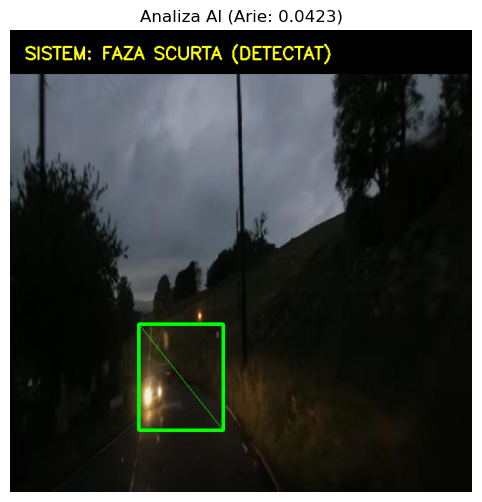

In [18]:

print("TEST 4 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i155_png.rf.a3759ac7a9f2ad79d805c51f0831c2da.jpg")


TEST 5 


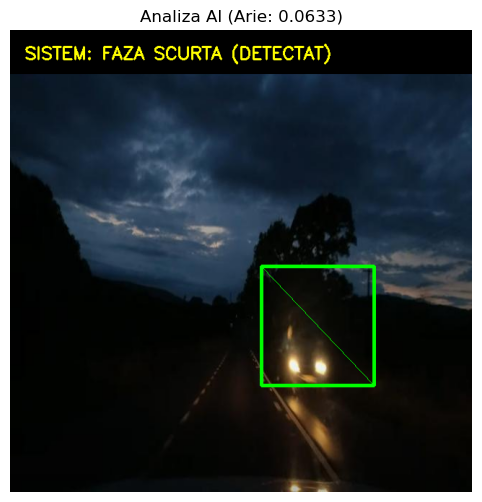

In [19]:

print("TEST 5 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\i2983_png.rf.595551d799bf2066e7e3fb2244add1f4.jpg")


TEST 4 


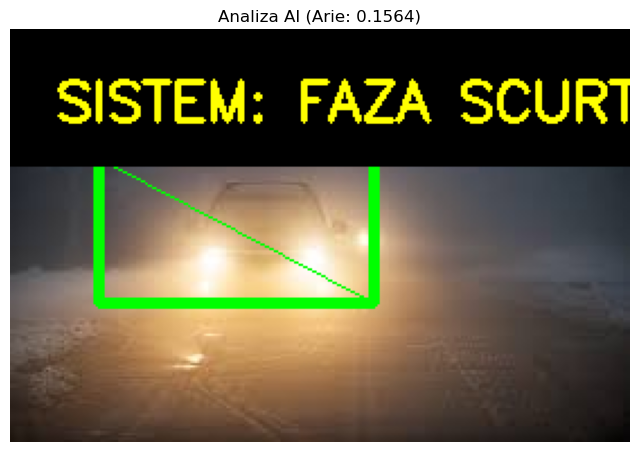

In [21]:

print("TEST 4 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\test\images\images_test2.jpg")



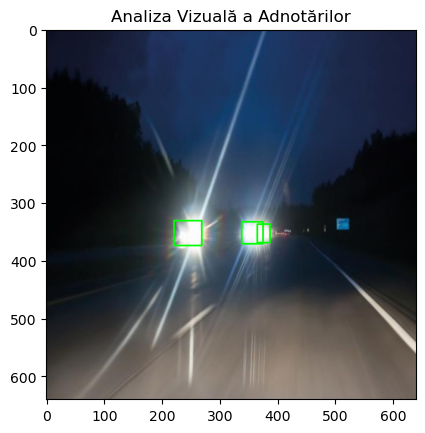

In [23]:
# Secțiune din cod pentru vizualizarea datelor (EDA)
def validare_vizuala(cale_img, cale_lbl):
    img = cv2.imread(cale_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with open(cale_lbl, 'r') as f:
        linii = f.readlines()
        for linie in linii:
            p = linie.split()
            h, w, _ = img.shape
            x_c, y_c, wb, hb = float(p[1])*w, float(p[2])*h, float(p[3])*w, float(p[4])*h
            x1, y1 = int(x_c - wb/2), int(y_c - hb/2)
            cv2.rectangle(img, (x1, y1), (int(x1+wb), int(y1+hb)), (0, 255, 0), 2)
    plt.imshow(img)
    plt.title("Analiza Vizuală a Adnotărilor")
    plt.show()
imagine_proba = r"C:\Users\Bianca\Documents\SBC-proiect\extracted\valid\images\i2_png.rf.07e0fc2735384a4977b5f5c1432189fe.jpg"
eticheta_proba = r"C:\Users\Bianca\Documents\SBC-proiect\extracted\valid\labels\i2_png.rf.07e0fc2735384a4977b5f5c1432189fe.txt"
validare_vizuala(imagine_proba, eticheta_proba)

TEST 5 


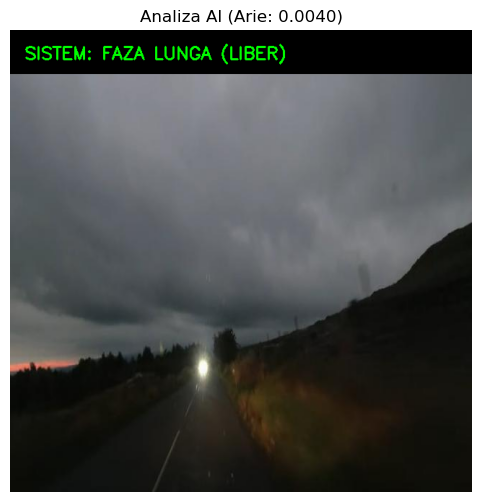

In [24]:
print("TEST 5 ")
faza_automata(r"C:\Users\Bianca\Documents\SBC-proiect\extracted\valid\images\i79_png.rf.42cc79c6d22034af76e539a53a492cf8.jpg")

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,915,470 (37.82 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,314 (25.22 MB)